<div style="box-sizing: border-box; width: 100%; max-width: 100%; background: linear-gradient(135deg, #0f172a 0%, #1e293b 60%, #0f172a 100%); padding: 28px 32px; border-radius: 16px; border: 1.5px solid rgba(56, 189, 248, 0.35); border-left: 6px solid #38bdf8; box-shadow: 0 10px 25px -5px rgba(0, 0, 0, 0.4), 0 8px 10px -6px rgba(0, 0, 0, 0.3); font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; margin: 10px 0 24px 0; overflow: hidden; color: #f8fafc;">

  <!-- Topic Badges -->
  <div style="display: flex; align-items: center; gap: 5px; margin-bottom: 14px; flex-wrap: wrap;">
    <span style="background: rgba(74, 222, 128, 0.15); color: #4ade80; font-size: 0.75rem; font-weight: 600; padding: 4px 12px; border-radius: 9999px; border: 1px solid rgba(74, 222, 128, 0.35); text-transform: uppercase; letter-spacing: 0.05em;">Autumn 2026</span>
    <span style="background: rgba(251, 191, 36, 0.15); color: #fbbf24; font-size: 0.75rem; font-weight: 600; padding: 4px 12px; border-radius: 9999px; border: 1px solid rgba(251, 191, 36, 0.35); text-transform: uppercase; letter-spacing: 0.05em;">IIT KGP</span>
  </div>

  <!-- Course Title -->
  <h1 style="color: #ffffff; font-size: 1.85rem; font-weight: 700; margin: 0 0 6px 0; border: none; padding: 0; letter-spacing: -0.02em; line-height: 1.2;">
    AI31201 &bull; <a href="https://ranjan-sarkar.github.io/#rl" target="_blank" style="color: #ffffff; text-decoration: none; border-bottom: 1.5px dashed rgba(56, 189, 248, 0.5);">Reinforcement Learning (RL)</a>
  </h1>

  <!-- Tutorial Subtitle -->
  <h2 style="color: #93c5fd; font-size: 1.45rem; font-weight: 600; margin: 0 0 14px 0; border: none; padding: 0; letter-spacing: -0.01em;">
    Tutorial 5: Monte Carlo Prediction &bull; Blackjack
  </h2>

  <!-- Instructor / TA Info Row -->
  <div style="display: flex; gap: 16px; margin-bottom: 16px; flex-wrap: wrap; font-size: 0.95rem; color: #cbd5e1; gap: 4px">
    <div>
      <span style="color: #94a3b8; font-weight: 600;">Instructor:</span>
      <a href="https://prabhatkmishra.github.io/people.html" target="_blank" style="color: #f1f5f9; font-weight: 600; text-decoration: none; margin-left: 4px;">Dr. Prabhat Kumar Mishra</a>
    </div>
    <div>
      <span style="color: #94a3b8; font-weight: 600;">TAs:</span>
      <a href="https://ranjan-sarkar.github.io" target="_blank" style="color: #f1f5f9; font-weight: 600; text-decoration: none; margin-left: 4px;">Ranjan Sarkar</a>
    </div>
  </div>

  <!-- Reference & Quick Links Footer -->
  <div style="padding-top: 14px; border-top: 1px solid rgba(255, 255, 255, 0.1); display: flex; align-items: center; gap: 10px; flex-wrap: wrap;">
    <span style="color: #64748b; font-size: 0.8rem; font-weight: 700; text-transform: uppercase; letter-spacing: 0.05em;">References:</span>
    <a href="http://incompleteideas.net/book/the-book-2nd.html" target="_blank" style="color: #c084fc; font-size: 0.85rem; font-weight: 600; text-decoration: none; background: rgba(168, 85, 247, 0.1); padding: 5px 12px; border-radius: 6px; border: 1px solid rgba(168, 85, 247, 0.25); display: inline-flex; align-items: center; gap: 4px;">
      📖 Sutton &amp; Barto (Section 5.1 &amp; Example 5.1) ↗
    </a>
  </div>

</div>

# 1. Blackjack (Sutton & Barto, Example 5.1)

New to blackjack? Watch this short video for the basic rules: [How to play Blackjack (YouTube)](https://www.youtube.com/watch?v=TDkbWXJ16hU)

**Terms**
| Term | Meaning |
|---|---|
| **Player** | The agent (us). Plays against the dealer. |
| **Dealer** | The opponent. Follows a fixed rule (part of the environment). |
| **Card sum** | Total value of the cards in a hand. |
| **Face cards** | Jack, Queen, King. Each counts as **10**. |
| **Ace** | Counts as either **1** or **11**. |
| **Usable ace** | An ace that can count as 11 **without** the sum going over 21. |
| **Dealer's showing card** | The dealer's one face-up card (the other is hidden). |
| **Hit** | Ask for one more card. |
| **Stick** | Stop taking cards; the turn ends. |
| **Bust** | Card sum goes over 21. The hand loses immediately. |
| **Natural** | 21 with the first two cards (an ace + a 10-valued card). |
| **Infinite deck** | Cards are drawn with replacement, so past cards give no information. |

**Rules**
1. Player and dealer each get **2 cards**. One dealer card is face up.
2. **Natural:** if the player has a natural, they win, unless the dealer also has one (then it is a draw).
3. **Player's turn:** hit or stick repeatedly. If the player goes bust, they **lose**.
4. **Dealer's turn:** the dealer hits until their sum is **17 or more**, then sticks. If the dealer goes bust, the player **wins**.
5. Otherwise, the sum **closer to 21** wins; equal sums are a **draw**.
6. Reward at the end of the game: **+1** win, **0** draw, **−1** lose.

**MDP**
- State: $s = (\text{player sum } 12\text{–}21,\ \text{dealer card } A\text{–}10,\ \text{usable ace?})$ → $10 \times 10 \times 2 = 200$ states
- Actions: $\{\text{stick}, \text{hit}\}$
- $\gamma = 1$ and all intermediate rewards are 0, so the return is just the final reward: $G_t = R_T$

**Policy to evaluate:** stick if player sum is 20 or 21, otherwise hit.

**Goal:** estimate $v_\pi(s) = \mathbb{E}_\pi[\,G_t \mid S_t = s\,]$ using only simulated games (no model $p(s',r|s,a)$ needed).

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

from IPython import get_ipython
ipython = get_ipython()
# for better resolution of plots in Notebook
ipython.run_line_magic('config', "InlineBackend.figure_format = 'retina'")

# Matplotlib style: Times New Roman text and matching math font
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'serif']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150

random.seed(0)

# 2. Environment

A **usable ace** is an ace that can count as 11 without going bust:
$$\text{hand value} = \begin{cases} \text{sum} + 10 & \text{if the hand has an ace and sum} + 10 \le 21 \\ \text{sum} & \text{otherwise} \end{cases}$$

In [2]:
STICK, HIT = 0, 1


def draw_card():
    # 1 = Ace, 2..10; J, Q, K also count as 10
    return min(random.randint(1, 13), 10)


def hand_value(hand):
    # returns (value, usable_ace)
    total = sum(hand)
    if 1 in hand and total + 10 <= 21:
        return total + 10, True
    return total, False


def play_episode(policy):
    '''Plays one game. Returns the episode as a list of (S_t, R_{t+1}).'''
    player = [draw_card(), draw_card()]
    dealer = [draw_card(), draw_card()]
    while hand_value(player)[0] < 12:          # sum < 12: always hit, no risk of bust
        player.append(draw_card())

    # ---- Player's turn ----
    episode = []
    while True:
        total, usable_ace = hand_value(player)
        state = (total, dealer[0], usable_ace)
        if policy(state) == STICK:
            break
        player.append(draw_card())
        if hand_value(player)[0] > 21:         # player bust -> lose
            episode.append((state, -1))
            return episode
        episode.append((state, 0))

    # Natural (21 with first two cards): win, unless dealer also has a natural
    if len(player) == 2 and total == 21:
        dealer_natural = hand_value(dealer)[0] == 21
        episode.append((state, 0 if dealer_natural else 1))
        return episode

    # ---- Dealer's turn: hit until sum >= 17 ----
    while hand_value(dealer)[0] < 17:
        dealer.append(draw_card())

    p, d = hand_value(player)[0], hand_value(dealer)[0]
    reward = 1 if (d > 21 or p > d) else (0 if p == d else -1)
    episode.append((state, reward))
    return episode

In [4]:
def policy(state):
    # stick on 20 or 21, otherwise hit
    player_sum, dealer_card, usable_ace = state
    return STICK if player_sum >= 20 else HIT


# One sample episode: list of (state, reward)
random.seed(44)
play_episode(policy)

[((16, 9, False), 0), ((18, 9, False), 0), ((21, 9, False), 1)]

# 3. First-Visit Monte Carlo Prediction

**Idea:** $v_\pi(s)$ is an expected return, so estimate it by **averaging the returns** seen after visiting $s$:
$$V(s) = \frac{1}{N(s)} \sum_{i=1}^{N(s)} G_i(s) \;\longrightarrow\; v_\pi(s) \quad \text{as } N(s) \to \infty$$

Here, $N(s)$ is the number of episodes so far in which state $s$ was visited (counting only the first visit in each episode), and $G_i(s)$ is the return that followed the $i$-th of these visits.

Instead of storing all returns, use the **incremental mean**:
$$N(S_t) \leftarrow N(S_t) + 1, \qquad V(S_t) \leftarrow V(S_t) + \frac{1}{N(S_t)}\big[\,G - V(S_t)\,\big]$$

**Pseudocode** (Sutton & Barto, Section 5.1, with the incremental mean)

$$
\begin{aligned}
&\boxed{\textbf{First-visit MC prediction, for estimating } V \approx v_\pi} \\[6pt]
&\textbf{Input: } \text{a policy } \pi \text{ to be evaluated} \\[4pt]
&\textbf{Initialize: } \\
&\qquad V(s) \leftarrow 0, \quad N(s) \leftarrow 0, \quad \text{for all } s \in \mathcal{S} \\[4pt]
&\textbf{Loop forever } \text{(for each episode):} \\
&\qquad \text{Generate an episode following } \pi: \ S_0, A_0, R_1, S_1, A_1, R_2, \dots, S_{T-1}, A_{T-1}, R_T \\
&\qquad G \leftarrow 0 \\
&\qquad \textbf{Loop for each step of episode, } t = T-1, T-2, \dots, 0: \\
&\qquad\qquad G \leftarrow \gamma G + R_{t+1} \\
&\qquad\qquad \textbf{Unless } S_t \text{ appears in } S_0, S_1, \dots, S_{t-1}: \quad \text{(first visit)} \\
&\qquad\qquad\qquad N(S_t) \leftarrow N(S_t) + 1 \\
&\qquad\qquad\qquad V(S_t) \leftarrow V(S_t) + \dfrac{1}{N(S_t)}\big[\,G - V(S_t)\,\big]
\end{aligned}
$$

*Note:* in blackjack a state never repeats within an episode, so first-visit and every-visit MC give the same result.

In [5]:
def mc_prediction(policy, num_episodes, gamma=1.0):
    V = np.zeros((10, 10, 2))   # index: [player_sum - 12, dealer_card - 1, usable_ace]
    N = np.zeros((10, 10, 2))   # visit counts

    for _ in range(num_episodes):
        episode = play_episode(policy)
        G = 0
        for t in reversed(range(len(episode))):
            state, reward = episode[t]
            G = gamma * G + reward                          # G <- gamma*G + R_{t+1}
            if state not in [s for s, _ in episode[:t]]:   # first visit only
                i = (state[0] - 12, state[1] - 1, int(state[2]))
                N[i] += 1
                V[i] += (G - V[i]) / N[i]                   # incremental mean
    return V


random.seed(0)
V_10k = mc_prediction(policy, 10_000)
V_500k = mc_prediction(policy, 500_000)

# 4. Results (Figure 5.1)

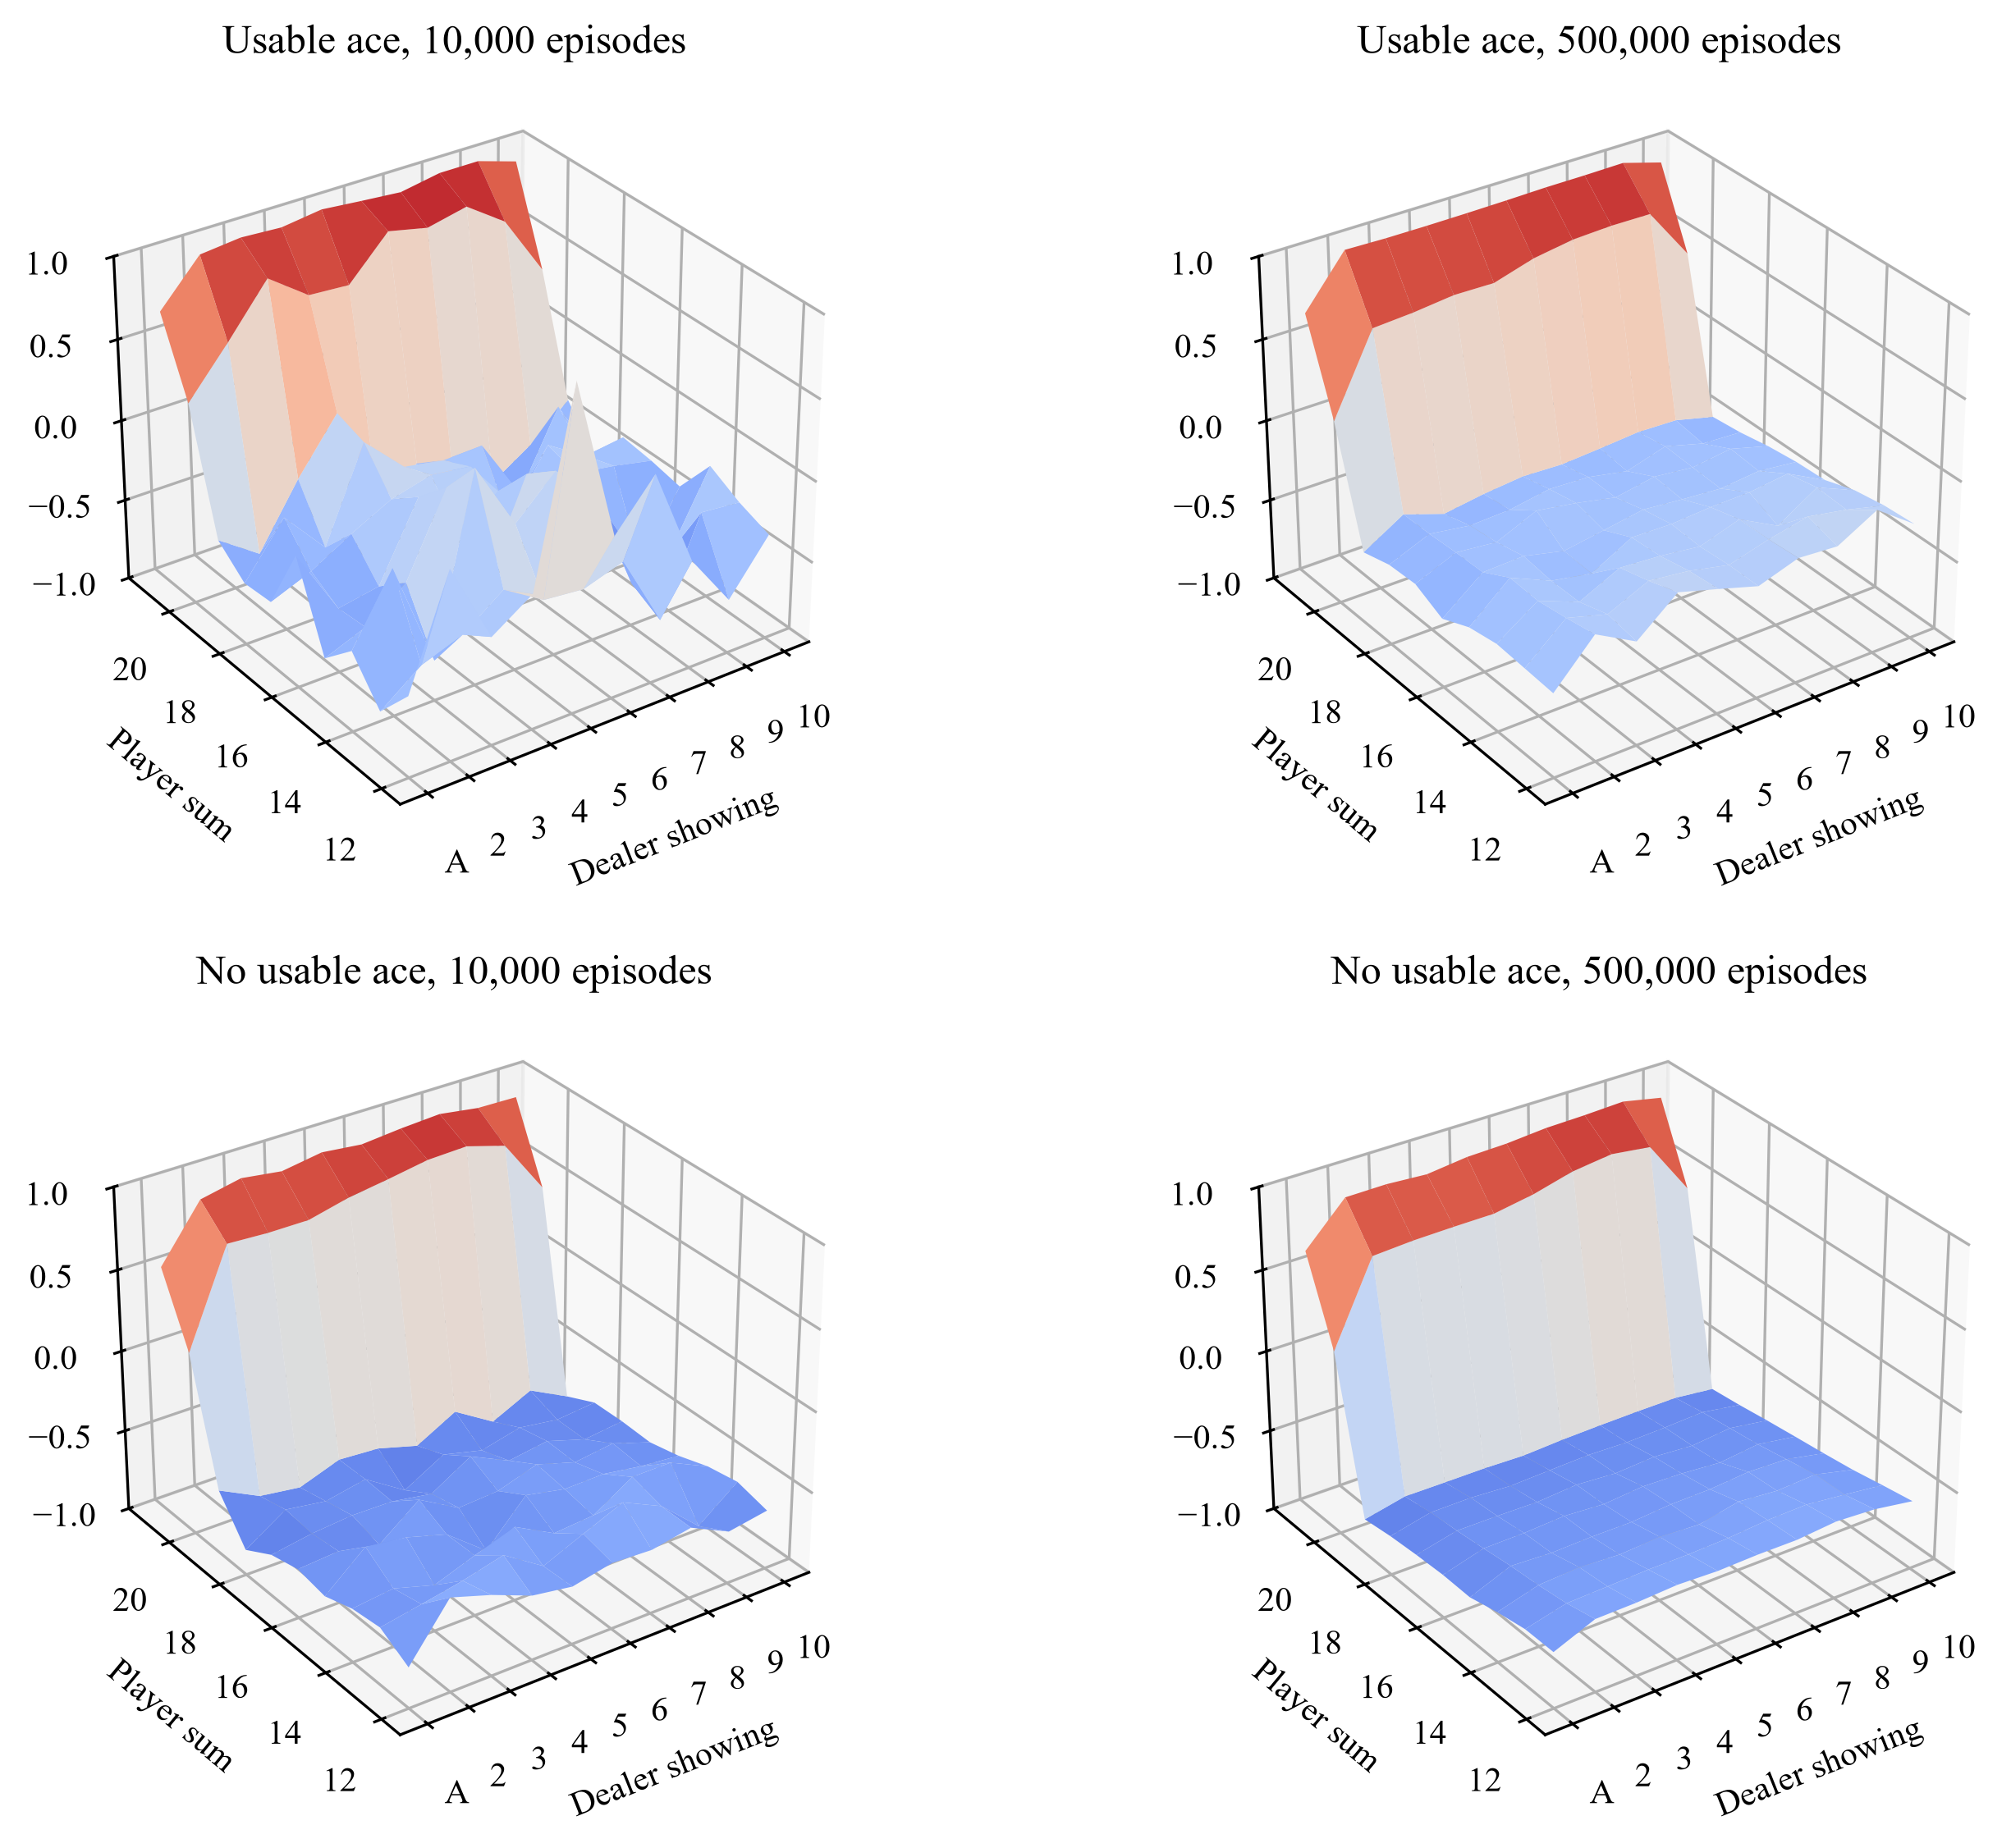

In [6]:
X, Y = np.meshgrid(np.arange(1, 11), np.arange(12, 22))   # dealer card (A=1), player sum

fig = plt.figure(figsize=(11, 9))
plots = [(V_10k, 1, 'Usable ace, 10,000 episodes'),
         (V_500k, 1, 'Usable ace, 500,000 episodes'),
         (V_10k, 0, 'No usable ace, 10,000 episodes'),
         (V_500k, 0, 'No usable ace, 500,000 episodes')]

for k, (V, ace, title) in enumerate(plots):
    ax = fig.add_subplot(2, 2, k + 1, projection='3d')
    ax.plot_surface(X, Y, V[:, :, ace], cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_title(title)
    ax.set_xlabel('Dealer showing')
    ax.set_ylabel('Player sum')
    ax.set_zlim(-1, 1)
    ax.set_xticks(range(1, 11), ['A'] + [str(i) for i in range(2, 11)])
    ax.view_init(elev=30, azim=-125)

plt.show()

**Observations**
- After 10,000 episodes the *usable ace* plot is still noisy: those states are rare, so they have fewer samples. After 500,000 episodes both are smooth.
- Value jumps up at player sum **20–21**: the policy sticks there, and these are strong hands.
- Value drops when the dealer shows an **ace**: the dealer is then strong.
- Low sums are better **with a usable ace**: the player cannot bust on the next hit.